### Automatyczne streszczanie tekstów

**Przykład ekstrakcyjnego streszczania** - zbiór najbardziej reprezentatywnych oryginalnych zdań z tekstu źródłowego. Zdania nie są przerabiane, parafrazowane ani upraszczane — zostają dokładnie takie, jakie były w tekście.


**streszczanie generatywne** - tworzy nowe zdania na podstawie zrozumienia całego tekstu, może łączyć informacje z kilku zdań w jedno, stosowane jest przez modele typu BART, T5 czy GPT.

In [16]:
import nltk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse.linalg import svds
import pandas as pd
import seaborn as sns


from gensim.summarization.summarizer import summarize as gensim_summarize # wymagana wersja 3.8.3 (nie jest wspierana przez python >3.8)


### Przykład tekstu w języku angielskim i polskim

In [7]:
text = """
Natural language processing is a field of computer science and artificial intelligence concerned with the interactions between computers and human languages.
In particular, it focuses on programming computers to process and analyze large amounts of natural language data.
The goal is a computer capable of understanding the contents of documents, including the contextual nuances of the language within them.
Technology such as summarization, machine translation, named entity recognition, and sentiment analysis all fall under NLP.
NLP is used in real-world applications such as chatbots, voice assistants, and search engines.
Recent advances in deep learning and transformers have significantly improved the accuracy of NLP systems.
"""

In [32]:
text = """
Polska to kraj w Europie Środkowej, o bogatej historii i kulturze. 
Znana jest z pięknych zabytków, takich jak Wawel w Krakowie czy Stare Miasto w Warszawie. 
Polacy słyną z gościnności oraz licznych tradycji przekazywanych z pokolenia na pokolenie. 
Krajobraz Polski jest zróżnicowany – od gór na południu po wybrzeże Morza Bałtyckiego na północy. 
W ostatnich latach Polska rozwija się dynamicznie, stając się ważnym graczem na arenie międzynarodowej.
"""

In [40]:
text = """
Warszawa, miasto stołeczne Warszawa – stolica Polski i województwa mazowieckiego, najludniejsze miasto w kraju i drugie (po Gdańsku) pod względem powierzchni, położone w jego centralnej części, na Nizinie Środkowomazowieckiej, na Mazowszu, nad Wisłą. Warszawa uzyskała prawa miejskie przed 1300 W 1526 została włączona do Korony Królestwa Polskiego. W 1569 mocą unii lubelskiej została ustanowiona miejscem obrad sejmów Rzeczypospolitej Obojga Narodów. Od 1573 odbywały się tam wolne elekcje. Po 1596 do Warszawy przeniesiono dwór królewski i urzędy centralne, a w 1611 w rozbudowanym Zamku Królewskim na stałe zamieszkał król Zygmunt III Waza. Miejsce obrad sejmików generalnych województwa mazowieckiego i sejmików ziemskich ziemi warszawskiej od XVI wieku do pierwszej połowy XVIII wieku. Po rozbiorach Polski przejściowo w Królestwie Prus, a następnie stolica Księstwa Warszawskiego i Królestwa Polskiego; od odzyskania niepodległości przez Polskę w 1918 roku – jej stolica. Doznała znacznych zniszczeń podczas II wojny światowej, kiedy to stała się areną walk powstańczych (najpierw w getcie, a później w całym mieście). Odbudowane po wojnie Stare Miasto zostało wpisane na listę światowego dziedzictwa UNESCO.
Jest jedynym polskim miastem, którego ustrój jest określony odrębną ustawą. Od 2002 jest gminą miejską mającą status miasta na prawach powiatu. W jej skład wchodzi 18 jednostek pomocniczych – dzielnic m.st. Warszawy.
Warszawa jest ważnym ośrodkiem naukowym, kulturalnym, politycznym oraz gospodarczym. Tutaj znajdują się siedziby m.in. Prezydenta RP, Sejmu i Senatu, Rady Ministrów oraz Narodowego Banku Polskiego. Warszawa jest także siedzibą agencji Frontex, odpowiedzialnej za bezpieczeństwo granic zewnętrznych Unii Europejskiej, oraz Biura Instytucji Demokratycznych i Praw Człowieka (ODIHR), agendy OBWE.
Think tank Globalization and World Cities (GaWC), badający wzajemne stosunki pomiędzy miastami świata w kontekście globalizacji, zaliczył Warszawę do kategorii Alpha- w 2000 roku i Alpha w 2024 roku.
Nazwa miasta zaczęła pojawiać się w dokumentach w XIV wieku jako Warszewa, a od XV wieku również jako Warszowa. Najprawdopodobniej pochodzi od formy dzierżawczej imienia Warsz (skróconej formy staropolskiego imienia Warcisław lub Wrocisław). Było ono używane m.in. przez przedstawicieli rodu Rawów (Rawiczów) herbu Rawa, którzy byli właścicielami terenów w rejonie współczesnego Solca. Prawdopodobnie Warsz z rodu Rawów otrzymał w XIII wieku nadanie książęce, z którego powstała wieś nosząca jego imię.
Zmiana nazwy na Warszawa w XV wieku wynikała z mazowieckiej wymowy dialektycznej. Do końca XV wieku samogłoska -a- przechodziła w -e- po spółgłoskach miękkich (-sz- była w tamtym okresie spółgłoską miękką). W XV wieku formy z wtórnym -e- zaczęły być postrzegane jako gwarowe[15]. Dlatego też zastępowano -e- przez -a-. Taka zmiana nie była uzasadniona etymologicznie, stąd takie formy nazywa się hiperpoprawnymi (np. siadlisko, królawski). Zmiana nazwy z Warszewa na Warszawa upowszechniła się w XVI wieku.
Legendarna etymologia wywodzi nazwę miasta od imion Warsa i jego żony Sawy."""

### Podsumowanie za pomocą bibl. Gensim
Cechy Gensim:
- Modelowanie tematów: wykrywa ukryte tematy w dokumentach za pomocą algorytmów takich jak LDA (Latent Dirichlet Allocation) czy LSI (Latent Semantic Indexing)
- Tworzenie wektorów słów i dokumentów: np. za pomocą Word2Vec, Doc2Vec, FastText
- Porównywanie dokumentów: oblicza podobieństwo semantyczne między tekstami
- Streszczanie tekstów: np. funkcja summarize() oparta na algorytmie TextRank
- Obsługa dużych zbiorów danych: działa w trybie strumieniowym, nie wymaga ładowania całego korpusu do pamięci RAM

In [44]:
print("Podsumowanie za pomocą Gensim:")
summary_gensim = ""
try:
    summary_gensim = gensim_summarize(text, ratio=0.2)
  
except ValueError:
    print("Tekst za krótki do podsumowania przez Gensim")

print(f"Długość tekstu oryginalnego: {len(text)} znaków, długość podsumowania: {len(summary_gensim)} znaków")
print(f"Ilość zdań tekstu oryginalnego: {len(text.split('.'))}, ilość zdań podsumowania: {len(summary_gensim.split('.'))}")
print()
print(summary_gensim)


Podsumowanie za pomocą Gensim:
Długość tekstu oryginalnego: 3113 znaków, długość podsumowania: 662 znaków
Ilość zdań tekstu oryginalnego: 35, ilość zdań podsumowania: 7

Po rozbiorach Polski przejściowo w Królestwie Prus, a następnie stolica Księstwa Warszawskiego i Królestwa Polskiego; od odzyskania niepodległości przez Polskę w 1918 roku – jej stolica.
Nazwa miasta zaczęła pojawiać się w dokumentach w XIV wieku jako Warszewa, a od XV wieku również jako Warszowa.
Prawdopodobnie Warsz z rodu Rawów otrzymał w XIII wieku nadanie książęce, z którego powstała wieś nosząca jego imię.
Zmiana nazwy na Warszawa w XV wieku wynikała z mazowieckiej wymowy dialektycznej.
Taka zmiana nie była uzasadniona etymologicznie, stąd takie formy nazywa się hiperpoprawnymi (np.
Zmiana nazwy z Warszewa na Warszawa upowszechniła się w XVI wieku.


### Analiza statystyczna tekstu

**TF-IDF (Term Frequency – Inverse Document Frequency)**
To sposób reprezentacji tekstu, w którym:
- słowa częste w konkretnym zdaniu mają większą wagę (TF)
- ale słowa, które są zbyt częste w całym tekście, mają mniejszą wagę (IDF) Czyli: faworyzujemy terminy ważne dla danego zdania, ale unikalne względem całego tekstu.

**Efekt końcowy: każde zdanie staje się wektorem liczbowym, odzwierciedlającym jego zawartość.**

SVD (Singular Value Decomposition)
To technika redukcji wymiarowości:
- z macierzy TF-IDF tworzymy zbiór tzw. ukrytych tematów (latent semantics)
- identyfikujemy najważniejsze "osie znaczeniowe" w tekście
- oceniamy, które zdania najbardziej pasują do tych osi

**Streszczenie**
- oceniamy, które zdania są "najlepszymi reprezentantami" głównych tematów (na podstawie wyników SVD)
- wybieramy np. dwa najważniejsze zdania i tworzymy z nich streszczenie


Analiza TF-IDF, podsumowanie SVD
Długość tekstu oryginalnego: 3201 znaków, długość podsumowania: 388 znaków
Ilość zdań tekstu oryginalnego: 37, ilość zdań podsumowania: 5

Warszawa, miasto stołeczne Warszawa[3] (m.st. Nazwa miasta zaczęła pojawiać się w dokumentach w XIV wieku jako Warszewa, a od XV wieku również jako Warszowa[15]. Zmiana nazwy na Warszawa w XV wieku wynikała z mazowieckiej wymowy dialektycznej. W XV wieku formy z wtórnym -e- zaczęły być postrzegane jako gwarowe[15]. Zmiana nazwy z Warszewa na Warszawa upowszechniła się w XVI wieku[18].


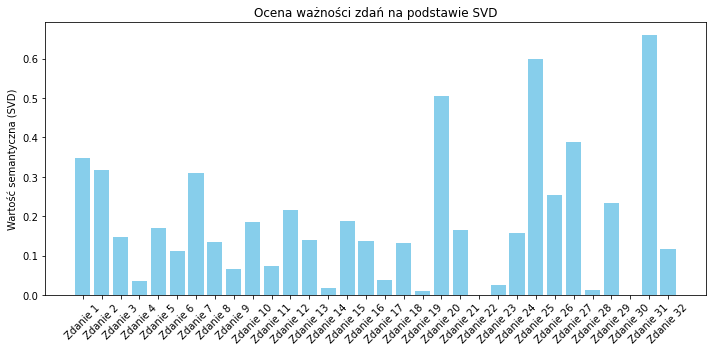

In [39]:
print("Analiza TF-IDF, podsumowanie SVD")

sentences = nltk.sent_tokenize(text)

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(sentences)

u, s, vt = svds(X, k=1)

sentence_scores = np.abs(u @ np.diag(s)).sum(axis=1)

top_n = 5
top_sentence_indices = sentence_scores.argsort()[-top_n:][::-1]
summary_svd = ' '.join([sentences[i] for i in sorted(top_sentence_indices)])
print(f"Długość tekstu oryginalnego: {len(text)} znaków, długość podsumowania: {len(summary_svd)} znaków")
print(f"Ilość zdań tekstu oryginalnego: {len(text.split('.'))}, ilość zdań podsumowania: {top_n}")
print(summary_svd)



plt.figure(figsize=(10, 5))
plt.bar(range(len(sentences)), sentence_scores, color='skyblue')
plt.xticks(range(len(sentences)), [f"Zdanie {i+1}" for i in range(len(sentences))], rotation=45)
plt.ylabel("Wartość semantyczna (SVD)")
plt.title("Ocena ważności zdań na podstawie SVD")
plt.tight_layout()
plt.show()


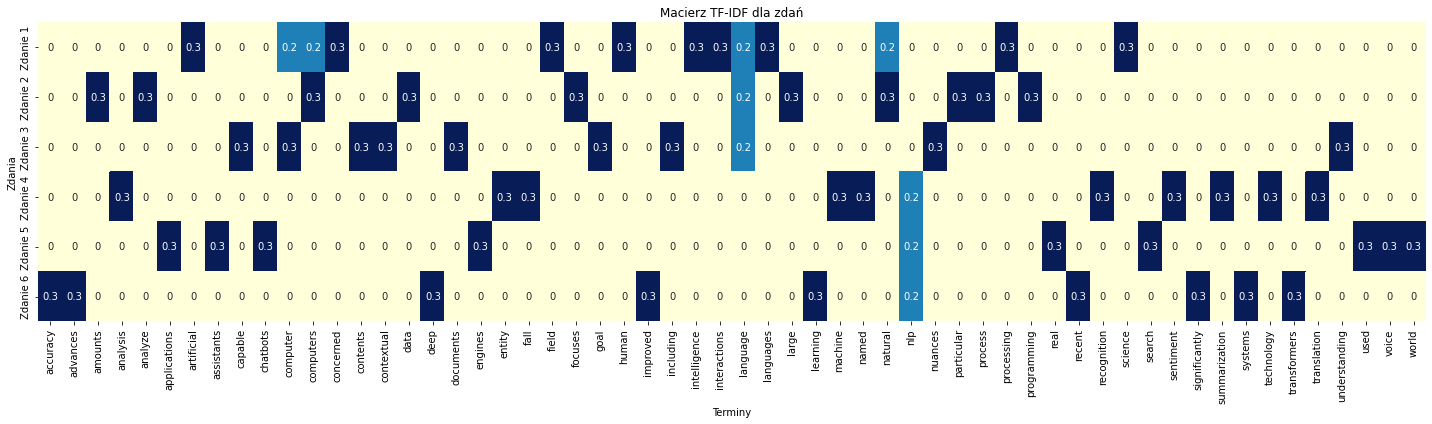

In [23]:
df_tfidf = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names(), index=[f"Zdanie {i+1}" for i in range(len(sentences))])
df_tfidf = df_tfidf.round(1)

plt.figure(figsize=(20, 6))
sns.heatmap(df_tfidf, annot=True, cmap="YlGnBu", cbar=False)
plt.title("Macierz TF-IDF dla zdań")
plt.xlabel("Terminy")
plt.ylabel("Zdania")
plt.tight_layout()
plt.show()

